In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import os

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from IPython.display import Image, display

In [ ]:
import keras
!python --version
print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

Python 3.10.12
TensorFlow Version: 2.17.0
Keras Version: 3.4.1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd/content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
data_dir = '/content/drive/MyDrive/classify/'
data_test = '/content/drive/MyDrive/test/'

In [ ]:
file_names = os.listdir(data_dir)
print(file_names)

['holybasil', 'kaffir lime leaves', 'lime', 'basil(โหระพา)', 'celery(ตั้งโอ๋)', 'coriander(ผักชี)', 'gourd(ตำลึง)', 'Mango yawns, lemon ho', 'turmeric(ขมิ้น)', 'ginger(ขิง)', 'chives leaves(ใบกุ๋ยช่าย)', 'galangal(ข่า)', ' cassia leaves(ใบขี้เหล็ก)', 'pandan leaf(ใบเตย)', 'climbing wattle(ชะอม)', 'lemon grass(ตะไคร้)', 'wild betel(ใบพลู)', 'spring onion(ต้นหอม)', 'finger root(กระชาย)', 'Bitter cucumber(มะระขี้นก)', 'project.h5', 'edit_model.keras', 'group1-shard1of3.bin', 'group1-shard2of3.bin', 'group1-shard3of3.bin', 'model.json']


In [ ]:
for file_name in file_names:
    data_dir2 = os.path.join(data_dir, file_name)
    print(data_dir2)
    if file_name.lower().endswith(('.jpg', '.png')):
        display(Image(filename=data_dir2))

/content/drive/MyDrive/classify/holybasil
/content/drive/MyDrive/classify/kaffir lime leaves
/content/drive/MyDrive/classify/lime
/content/drive/MyDrive/classify/basil(โหระพา)
/content/drive/MyDrive/classify/celery(ตั้งโอ๋)
/content/drive/MyDrive/classify/coriander(ผักชี)
/content/drive/MyDrive/classify/gourd(ตำลึง)
/content/drive/MyDrive/classify/Mango yawns, lemon ho
/content/drive/MyDrive/classify/turmeric(ขมิ้น)
/content/drive/MyDrive/classify/ginger(ขิง)
/content/drive/MyDrive/classify/chives leaves(ใบกุ๋ยช่าย)
/content/drive/MyDrive/classify/galangal(ข่า)
/content/drive/MyDrive/classify/ cassia leaves(ใบขี้เหล็ก)
/content/drive/MyDrive/classify/pandan leaf(ใบเตย)
/content/drive/MyDrive/classify/climbing wattle(ชะอม)
/content/drive/MyDrive/classify/lemon grass(ตะไคร้)
/content/drive/MyDrive/classify/wild betel(ใบพลู)
/content/drive/MyDrive/classify/spring onion(ต้นหอม)
/content/drive/MyDrive/classify/finger root(กระชาย)
/content/drive/MyDrive/classify/Bitter cucumber(มะระขี้นก)
/c

In [ ]:
def count_images(data_dir):
    image_count = sum(1 for file in os.listdir(data_dir) if file.lower().endswith(('.jpg', '.png')))
    return image_count

In [ ]:
group1_path = os.path.join(data_dir, 'pandan leaf')
group2_path = os.path.join(data_dir, 'kaffir lime leaves')
group3_path = os.path.join(data_dir, 'lime')

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2499 files belonging to 20 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_test,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2000 files belonging to 20 classes.


In [ ]:
class_names = train_ds.class_names
print(class_names)

[' cassia leaves(ใบขี้เหล็ก)', 'Bitter cucumber(มะระขี้นก)', 'Mango yawns, lemon ho', 'basil(โหระพา)', 'celery(ตั้งโอ๋)', 'chives leaves(ใบกุ๋ยช่าย)', 'climbing wattle(ชะอม)', 'coriander(ผักชี)', 'finger root(กระชาย)', 'galangal(ข่า)', 'ginger(ขิง)', 'gourd(ตำลึง)', 'holybasil', 'kaffir lime leaves', 'lemon grass(ตะไคร้)', 'lime', 'pandan leaf(ใบเตย)', 'spring onion(ต้นหอม)', 'turmeric(ขมิ้น)', 'wild betel(ใบพลู)']


/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from current font.
  func(*args, **kwargs)
/usr/local/lib/python3.10/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from current font.
 

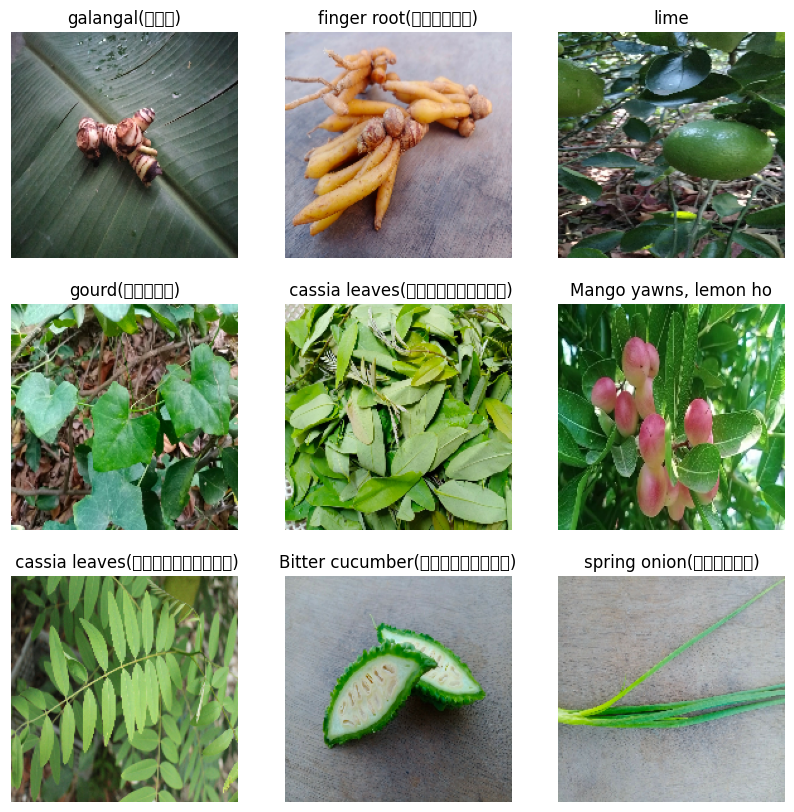

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [ ]:
normalization_layer = layers.Rescaling(1./255)

In [ ]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

KeyboardInterrupt: 

In [ ]:
num_classes = len(class_names)
model = Sequential([
    # `input_shape` is only required here so that `.summary` works.
    layers.Dense(512, activation='elu', input_shape=(img_height, img_width, 3)),
    layers.Dense(512, activation='elu'),
    layers.Dense(512, activation='elu'),
    layers.Dense(512, activation='elu'),
    layers.Dense(1),
    layers.Dense(num_classes)
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(256, activation='relu'),
  layers.Dense(num_classes)
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 22, 22, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 11, 11, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 15488)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       3,965,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 20)                  │           5,140 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,067,764 (15.52 MB)

 Trainable params: 4,067,764 (15.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs= 60
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 543s 7s/step - accuracy: 0.1361 - loss: 2.7967 - val_accuracy: 0.1255 - val_loss: 3.0468
Epoch 2/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4942 - loss: 1.7024 - val_accuracy: 0.1560 - val_loss: 3.3388
Epoch 3/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6430 - loss: 1.1220 - val_accuracy: 0.1675 - val_loss: 3.9043
Epoch 4/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7524 - loss: 0.7912 - val_accuracy: 0.1695 - val_loss: 4.2732
Epoch 5/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8292 - loss: 0.5536 - val_accuracy: 0.1745 - val_loss: 5.3381
Epoch 6/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8804 - loss: 0.3503 - val_accuracy: 0.1920 - val_loss: 6.9248
Epoch 7/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9065 - loss: 0.2982 - val_accuracy: 0.1875 - val_loss: 7.0189
Epoch 8/60
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9532 - loss: 0.1521 - val_accuracy: 0.1680 - v

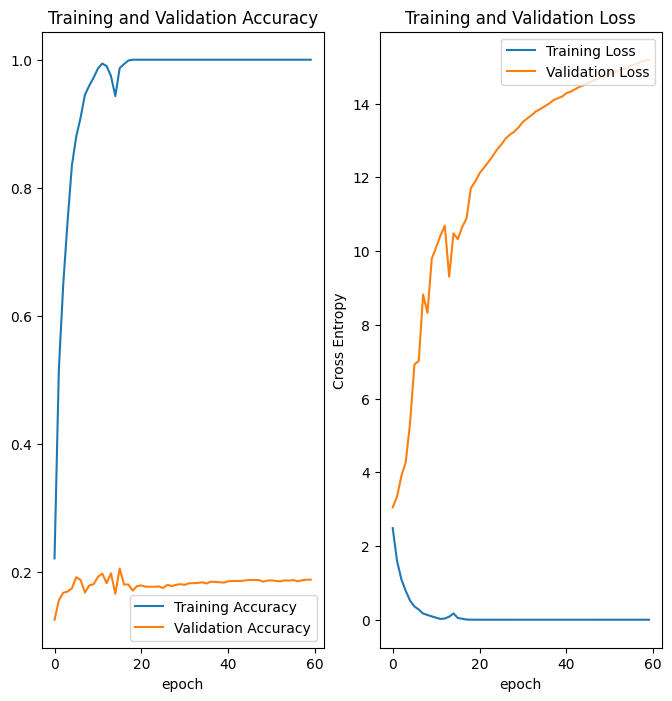

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('epoch')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

#save model


In [ ]:
# Create and train a new model instance.
model = create_model()
model.fit(train_images, train_labels, epochs=5)

# Save the entire model to a HDF5 file.
# The '.h5' extension indicates that the model should be saved to HDF5.
model.save('mymodel.h5')

NameError: name 'create_model' is not defined

In [ ]:
loaded_model = tf.keras.models.load_model("my_model")

In [ ]:
def display_random_image(val_ds, labels, class_names):
    # สุ่มเลือกภาพที่ต้องการแสดง
    index = np.random.randint(0, len(labels))

    # ดึงข้อมูลจาก PrefetchDataset ในรูปแบบ NumPy array
    val_iterator = iter(val_ds)
    for _ in range(index + 1):
        data = next(val_iterator)

    # ตรวจสอบโครงสร้างข้อมูลที่ถูกส่งมา
    print(data)
    plt.imshow(image[0])
    plt.show()


In [ ]:

# ตั้งค่าที่อยู่ของไฟล์รูปภาพที่ต้องการโหลด
image_fodername = 'ชะพลู.jpg'
data_dir3 = '/content/drive/MyDrive/classify/แยกภาพ/'  # ที่อยู่ของไฟล์รูปภาพ

# ต่อที่อยู่ของไฟล์รูปภาพเข้ากับชื่อไฟล์
img_path = os.path.join(data_dir3, image_fodername)

# โหลดรูปภาพ
new_img = tf.keras.utils.load_img(img_path, target_size=(180, 180))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/classify/แยกภาพ/ชะพลู.jpg'

In [ ]:
img_array = tf.keras.utils.img_to_array(new_img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

image_path = "/content/drive/MyDrive/TestT/content_carissa-carandas-medicinal-benefits.jpg"
new_img = image.load_img(image_path, target_size=(180, 180))
img = image.img_to_array(new_img)
img = np.expand_dims(img, axis=0)
img = img/255

predictions = model.predict(img)

# ค้นหาคลาสที่มีความน่าจะเป็นสูงสุด
img_class_index = np.argmax(predictions[0])
classname = class_names[img_class_index]

print(f'This image most likely belongs to {classname} with a confidence of {100 * predictions[0][img_class_index]:.2f}%')

# หากคุณต้องการความน่าจะเป็นของทุกคลาส
img_probs = predictions[0]
for i, prob in enumerate(img_probs):
    print(f'Class {class_names[i]}: {100 * prob:.2f}%')

# เพิ่มบล็อกการเข้ารหัสเพื่อป้องกัน IndentationError
pred_dict = {"Class":classname, "Probability":predictions[0][img_class_index]}

#ploting image with predicted class name
plt.figure(figsize = (4,4))
plt.imshow(new_img)
plt.axis('off')
plt.title(classname)
plt.show()

In [ ]:
# image_count =  len(list(data_dir))
# print(image_count)
# # image_dataset_from_directory
